# Cross-validation of NK cell annotation in the external Bulk RNA-seq dataset (Figure S5)

**Manuscript Context:** This notebook contains the code and workflows used to generate Figure S5a–h for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to cross-validate the biological relevance and robustness of our identified NK cell states using an external Bulk RNA-seq dataset. Specifically, we:
1.  Perform Principal Component Analysis (PCA) and K-means clustering to segregate bulk samples into "Classical" and "Non-classical" states based on global transcriptomic profiles.
2.  Overlay the expression of key signature genes (LMP-1, CD274, and H2AC11) onto the PCA space to confirm their spatial correlation with specific disease states.
3.  Generate a volcano plot to identify differentially expressed genes between states and perform Gene Set Enrichment Analysis (GSEA) to confirm the enrichment of EBV infection and Neutrophil extracellular trap formation pathways in the "Classical" state.
4.  Utilize BayesPrism to estimate cell-type proportions within the bulk samples and correlate the enrichment of specific genomic signatures (MaligNK_chr6p21Del vs. MaligNK_chr6p21Amp) with shifts in the tumor microenvironment.

In [51]:
import scanpy as sc
import pandas as pd
import gseapy as gp
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [4]:
figPath = './figures/figS5'
os.makedirs(figPath, exist_ok=True)
bulkPath = './data/OEP000498_processed.h5ad'
adata = sc.read_h5ad(bulkPath)

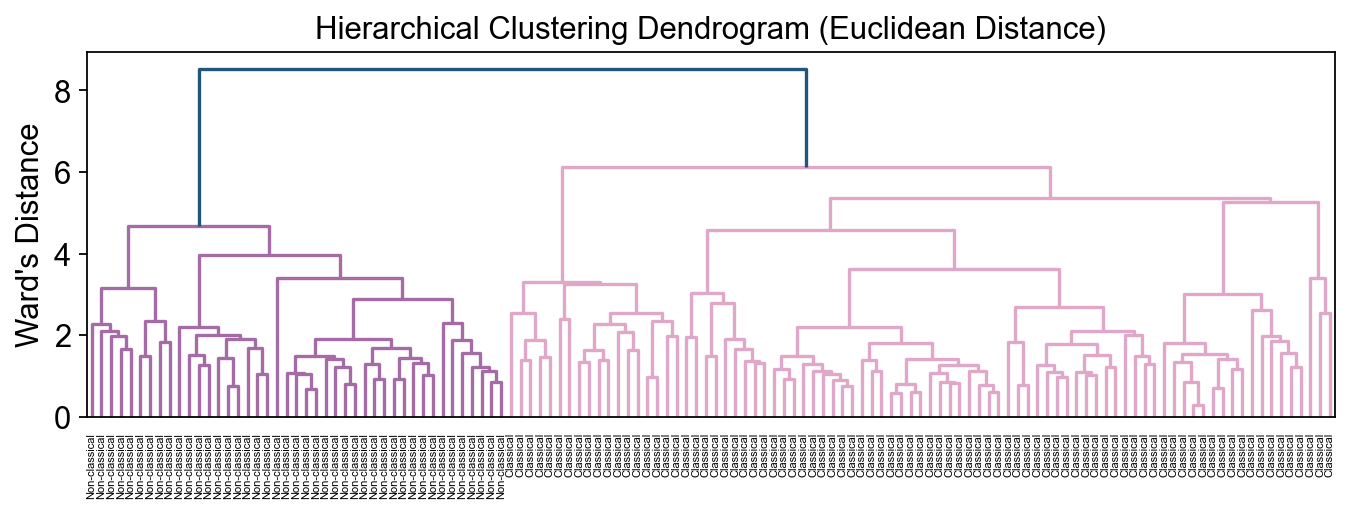

In [ ]:
# Hierarchical Clustering Based on Euclidean Distance after PCA Dimensionality Reduction
euclidean_dist = adata.obsp['distances'].todense()
linkage_matrix = linkage(euclidean_dist, method="ward")
optimal_k = 2 

adata.obs["hier_cluster"] = fcluster(linkage_matrix, optimal_k, criterion="maxclust")
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
adata.obs["kmeans_cluster"] = kmeans.fit_predict(adata.obsm["X_pca"])
adata.obs["hier_cluster"] = adata.obs["hier_cluster"].astype('category')
adata.obs["kmeans_cluster"] = adata.obs["kmeans_cluster"].astype('category')
#  Visualize hierarchical clustering dendrogram
fig, ax = plt.subplots(figsize=(10, 3))
dendrogram(linkage_matrix, labels=adata.obs['hier_anno'], color_threshold=7, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Euclidean Distance)")
ax.set_ylabel("Ward's Distance")
fig.savefig(f"{figPath}/FigS5h-Dendrogram.pdf")

#### **Fig. S5a-d** PCA visualization of K-means clustering (k=2) for the external dataset.
- S5a: PCA visualization distinguishing Classical and Non-classical sample states based on global transcriptomic profiles
- S5b: PCA projections overlaid with expression levels of LMP-1 (EBV-encoded oncogene)
- S5c: PCA projections overlaid with expression levels of CD274 (encoding PD-L1, immune checkpoint molecule)
- S5d: PCA projections overlaid with expression levels of H2AC11 (histone gene localized to chr6p22.1)

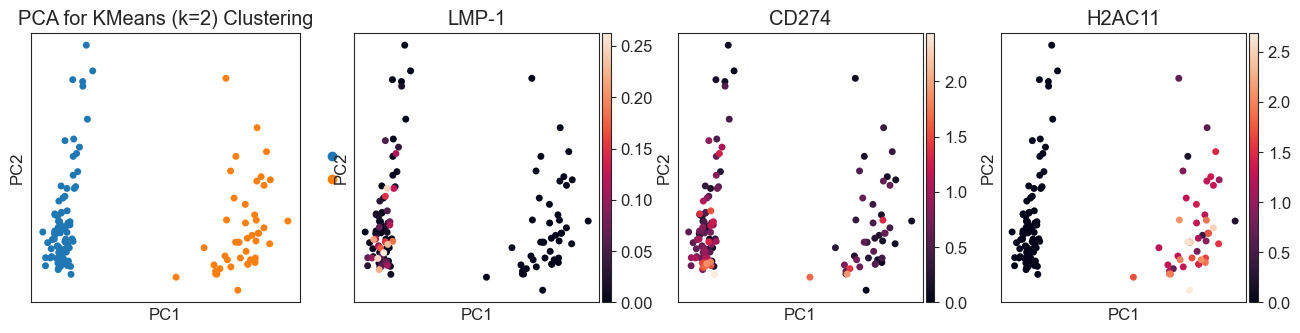

In [896]:
# Visualize PCA results for Hierarchical and Kmeans Clustering
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
sc.pl.pca(adata, color=['kmeans_anno'],
          title=["PCA for KMeans (k=2) Clustering"], ax=ax[0], show=False, s=100)
sc.pl.pca(adata, color=[ 'LMP-1'], ax=ax[1], show=False, s=100)
sc.pl.pca(adata, color=[ 'CD274'], ax=ax[2], show=False, s=100)
sc.pl.pca(adata, color=[ 'H2AC11'], ax=ax[3], show=False, s=100)
fig.savefig(f'{figPath}/FigS5a-d.pdf')

#### **Fig. S5e** Volcano plot of differentially expressed genes between Classical and Non-classical states. 
Genes are plotted by log₂ fold change (x-axis) and -log₁₀(adjusted P-value) (y-axis). 

In [6]:
# Calculate DEGs using pyDESeq2
import anndata as ad
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def run_deseq2(adata, group_key):
    # Check input validity
    if group_key not in adata.obs.columns:
        raise ValueError(f"Group key '{group_key}' not found in adata.obs")
    
    # Prepare data for DESeq2
    counts = pd.DataFrame(adata.layers['Raw'], 
                          index=adata.obs_names, columns=adata.var_names)  # Transpose to gene x sample format
    coldata = adata.obs[[group_key]].copy()
    dds = DeseqDataSet(
        counts=counts,
        metadata=coldata,
        design=f"~{group_key}"
    )
    
    # Run DESeq2 analysis
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=[group_key, 
                                         adata.obs[group_key].cat.categories[0], 
                                         adata.obs[group_key].cat.categories[1]])
    stat_res.summary()
    return adata, stat_res
adata, hier_stat = run_deseq2(adata, 'hier_anno')

Fitting size factors...
... done in 0.08 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.01 seconds.

Fitting dispersion trend curve...
... done in 0.82 seconds.

Fitting MAP dispersions...
... done in 2.36 seconds.

Fitting LFCs...
... done in 4.67 seconds.

Calculating cook's distance...
... done in 0.31 seconds.

Replacing 4594 outlier genes.

Fitting dispersions...
... done in 1.84 seconds.

Fitting MAP dispersions...
... done in 1.55 seconds.

Fitting LFCs...
... done in 2.20 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: hier_anno Classical vs Non-classical
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
DDX11L2          26.042220       -1.586878  0.255270 -6.216467  5.084727e-10   
MIR1302-2HG       1.541849        1.306472  0.463772  2.817057  4.846588e-03   
FAM138A           1.276313       -2.078651  0.855773 -2.428974  1.514163e-02   
ENSG00000290826   0.340668        1.967858  2.054629  0.957768  3.381798e-01   
OR4F5             0.160874        0.060352  1.544127  0.039085  9.688229e-01   
...                    ...             ...       ...       ...           ...   
BKRF2             0.176318        1.895687  1.853202  1.022925  3.063434e-01   
BBLF4             0.561627        2.992003  1.701813  1.758127  7.872591e-02   
BBRF1             0.340494        2.376211  1.801412  1.319082  1.871416e-01   
BBLF2/BBLF3       1.418266        4.348656  1.343847  3.235977  1.212273e-03   
BBRF3             1.002978        3.858173  1

... done in 3.24 seconds.



In [8]:
# Store results in AnnData
adata.var[f'hier_anno_log2FoldChange'] = hier_stat.results_df['log2FoldChange']
adata.var[f'hier_anno_pvalue'] = hier_stat.results_df['pvalue']
adata.var[f'hier_anno_padj'] = hier_stat.results_df['padj']

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text

def plot_volcano(results_df, 
                 pval_threshold=0.05, 
                 lfc_threshold=1.0,
                 top_n=20,
                 gene_list = None,
                 figsize=(5, 4),
                 title="Volcano Plot",
                 max_x=20,
                 max_y=300):
    """
    Plot volcano plot for differential expression analysis
    
    Parameters:
    results_df: DESeq2 results DataFrame containing log2FoldChange and padj columns
    pval_threshold: Significance threshold for p-values
    lfc_threshold: Log2 fold change threshold
    top_n: Number of top significant genes to label
    gene_list: Custom list of genes to highlight (optional)
    figsize: Figure size
    title: Plot title
    max_x: Maximum x-axis limit
    max_y: Maximum y-axis limit
    """
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Extract data
    log2fc = results_df['log2FoldChange']
    pvals = results_df['padj']
    gene_names = results_df.index
    
    # Handle missing values
    valid_mask = ~(np.isnan(log2fc) | np.isnan(pvals))
    log2fc = log2fc[valid_mask]
    pvals = pvals[valid_mask]
    gene_names = gene_names[valid_mask]
    
    # Calculate -log10(p-value)
    neg_log10_pvals = -np.log10(pvals)
    neg_log10_pvals = np.clip(neg_log10_pvals, 0, max_y)
    
    # Classify genes
    up_regulated = (log2fc > lfc_threshold) & (pvals < pval_threshold)
    down_regulated = (log2fc < -lfc_threshold) & (pvals < pval_threshold)
    not_significant = ~(up_regulated | down_regulated)
    
    # Plot scatter points
    plt.scatter(log2fc[not_significant], neg_log10_pvals[not_significant], 
                c='gray', alpha=0.5, s=20, label='ns.')
    plt.scatter(log2fc[up_regulated], neg_log10_pvals[up_regulated], 
                c='#2372a9', alpha=0.7, s=30, label='Classical')
    plt.scatter(log2fc[down_regulated], neg_log10_pvals[down_regulated], 
                c='#ef7c21', alpha=0.7, s=30, label='Non-classical')
    
    # Add threshold lines
    plt.axhline(-np.log10(pval_threshold), color='black', linestyle='--', alpha=0.8)
    plt.axvline(lfc_threshold, color='black', linestyle='--', alpha=0.8)
    plt.axvline(-lfc_threshold, color='black', linestyle='--', alpha=0.8)
    
    # Set axis properties
    plt.xlabel('log2 Fold Change', fontsize=12)
    plt.ylabel('-log10(Adjusted p-value)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(-max_x, max_x)  # Set x-axis maximum limit
    plt.ylim(0, max_y)      # Set y-axis maximum limit
    
    # Select genes for labeling
    significant_genes = gene_names.isin(gene_list) if gene_list is not None else up_regulated | down_regulated 
    if significant_genes.sum() > 0:
        # Sort by significance
        significance_scores = neg_log10_pvals[significant_genes] * np.abs(log2fc[significant_genes])
        top_indices = np.argsort(significance_scores)[-top_n:]
        top_gene_names = gene_names[significant_genes][top_indices]
        top_log2fc = log2fc[significant_genes][top_indices]
        top_neg_log10_pvals = neg_log10_pvals[significant_genes][top_indices]
        
        # Create annotation texts
        texts = []
        for gene, x, y in zip(top_gene_names, top_log2fc, top_neg_log10_pvals):
            texts.append(plt.text(x, y, gene, fontsize=9, 
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)))
        
        # Use adjustText to automatically adjust label positions
        adjust_text(texts, 
                   arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
                   expand_points=(1.2, 1.2),
                   force_text=(0.5, 0.5),
                   force_points=(0.5, 0.5))
    
    # Add legend and grid
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()

/home/rzh/miniconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


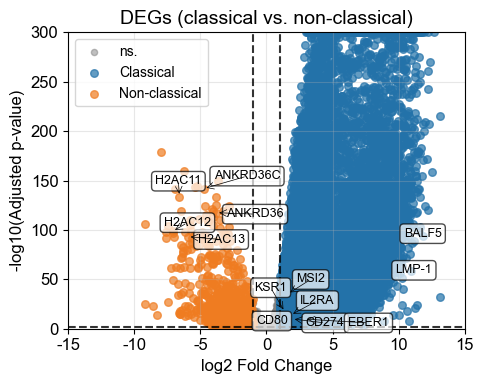

In [10]:
gene_list=['LMP-1', 'EBER1', 'BALF5', 'CD274', 'IL2RA', 'CD80', 'MSI2', 'KSR1',
           'H2AC11','H2AC12','H2AC13','ANKRD36', 'ANKRD36C']
fig = plot_volcano(hier_stat.results_df, max_x=15, gene_list=gene_list, title="DEGs (classical vs. non-classical)")
fig.savefig(f"{figPath}/FigS5e.png", dpi=150, bbox_inches='tight')

#### **Fig. S5f** KEGG pathway enrichment analysis (GSEA) of the EBV infection pathway in Classical (blue) and Non-classical (orange) states. 
Statistical significance was determined using the two-sided Wilcoxon test.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
from scipy import stats
from typing import List, Optional, Tuple, Dict, Any, Union

def plot_violin_stats(
    adata: sc.AnnData, 
    gene: str, 
    groupby: str, 
    ax: Optional[plt.Axes] = None, 
    figsize: Tuple[int, int] = (4, 5),
    jitter: float = 0.4,
    point_size: float = 1,
    order: Optional[List[str]] = None,
    show_p_value: bool = True,
    method: str = 'auto',
    comparisons: Optional[List[Tuple[str, str]]] = None
):
    """
    Plot violin plots with statistical significance markers.
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes object.
    stats_results : List[Dict] or Dict
        Detailed statistical results. 
        If pairwise comparisons: List of dicts containing 'group1', 'group2', 'statistic', 'pvalue', 'mean1', 'mean2', 'direction'.
        If global test: Dict containing 'statistic', 'pvalue', 'method'.
    method_name : str
        Name of the statistical method used.
    """
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    if gene not in adata.var_names and gene not in adata.obs.columns:
        raise ValueError(f"Gene '{gene}' not found.")
    if groupby not in adata.obs.columns:
        raise ValueError(f"Group column '{groupby}' not found.")
    
    # Handle categories and order
    all_categories = list(adata.obs[groupby].astype('category').cat.categories)
    if order:
        categories = [c for c in order if c in all_categories]
    else:
        categories = all_categories
        
    if len(categories) < 2:
        raise ValueError("Need at least 2 groups for statistical testing.")
    
    # Extract data efficiently
    values_dict = {}
    for cat in categories:
        mask = adata.obs[groupby] == cat
        idx = np.where(mask)[0]
        if len(idx) > 0:
            if gene in adata.var_names:
                vals = adata[idx, gene].X.toarray().flatten() if hasattr(adata[idx, gene].X, "toarray") else adata[idx, gene].X.flatten()
            else:
                vals = adata.obs.loc[mask, gene].values
            values_dict[cat] = vals
        else:
            values_dict[cat] = np.array([])

    valid_groups = [g for g in categories if len(values_dict[g]) > 0]
    if len(valid_groups) < 2:
        raise ValueError("Less than 2 groups contain data.")
        
    group_data_map = {g: values_dict[g] for g in valid_groups}

    # Determine comparisons to perform
    tests_to_run = []
    global_stat_name = ""
    global_result = {}
    stats_results = [] # To store detailed results

    if comparisons:
        for g1, g2 in comparisons:
            if g1 not in valid_groups or g2 not in valid_groups:
                print(f"Warning: Skipping comparison ({g1}, {g2}) as one group is missing or empty.")
                continue
            tests_to_run.append((g1, g2))
    else:
        if len(valid_groups) == 2:
            tests_to_run.append((valid_groups[0], valid_groups[1]))
        else:
            # Global test for >2 groups
            group_data_list = [group_data_map[g] for g in valid_groups]
            stat_val, p_val = stats.kruskal(*group_data_list)
            global_stat_name = "Kruskal-Wallis"
            global_result = {
                'method': global_stat_name,
                'statistic': stat_val,
                'pvalue': p_val,
                'groups_compared': valid_groups
            }
            # For global test, we return the global_result as the main stats object if no pairwise requested
            if not tests_to_run: 
                stats_results = global_result 

    # Plot Violin
    try:
        sc.pl.violin(
            adata, keys=[gene], groupby=groupby, ax=ax, show=False, 
            order=order, ylabel=gene, xlabel=''
        )
    except Exception:
        df = adata.obs.copy()
        if gene in adata.var_names:
            df[gene] = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, "toarray") else adata[:, gene].X.flatten()
        sns.violinplot(x=groupby, y=gene, data=df, ax=ax, order=order, jitter=jitter)
        ax.set_ylabel(gene)
        ax.set_xlabel('')

    # Get X positions
    ax.figure.canvas.draw() 
    x_ticks = list(ax.get_xticks())
    tick_labels = [str(label.get_text()) for label in ax.get_xticklabels()]
    
    pos_map = {}
    if len(x_ticks) == len(tick_labels):
        for pos, label in zip(x_ticks, tick_labels):
            pos_map[label] = pos
    else:
        if len(x_ticks) == len(valid_groups):
            for i, g in enumerate(valid_groups):
                pos_map[g] = x_ticks[i]
        else:
            # Fallback mapping based on order if labels are missing
            # This assumes the plot drew them in the order of 'valid_groups' or 'order'
            # A robust fallback is difficult without labels, but we try:
            current_order = order if order else valid_groups
            for i, g in enumerate(current_order):
                if g in valid_groups and i < len(x_ticks):
                    pos_map[g] = x_ticks[i]

    def get_star(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"

    y_min, y_max = ax.get_ylim()
    overall_max = max(np.max(v) if len(v)>0 else -np.inf for v in group_data_map.values())
    range_y = y_max - y_min
    if range_y == 0: range_y = 1
    
    current_height = overall_max
    
    # 1. Draw Pairwise Comparisons & Collect Stats
    if tests_to_run:
        stats_results = [] # Reset to list for pairwise
        for g1, g2 in tests_to_run:
            d1, d2 = group_data_map[g1], group_data_map[g2]
            stat_val, p_val = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            
            # Calculate descriptive stats
            m1, m2 = np.mean(d1), np.mean(d2)
            med1, med2 = np.median(d1), np.median(d2)
            
            # Determine direction
            if m1 > m2: direction = f"{g1} > {g2}"
            elif m2 > m1: direction = f"{g2} > {g1}"
            else: direction = "Equal"
            
            res_dict = {
                'group1': g1, 'group2': g2,
                'statistic': stat_val, # U value
                'pvalue': p_val,
                'mean1': m1, 'mean2': m2,
                'median1': med1, 'median2': med2,
                'direction': direction,
                'method': 'Mann-Whitney U'
            }
            stats_results.append(res_dict)
            
            # Plotting logic
            if p_val < 0.05 and show_p_value:
                if g1 not in pos_map or g2 not in pos_map:
                    continue
                    
                x1, x2 = pos_map[g1], pos_map[g2]
                offset = range_y * 0.05
                bar_height = offset * 0.5
                y_line = current_height + offset
                
                ax.plot([x1, x2], [y_line, y_line], color='black', linewidth=1.2)
                ax.plot([x1, x1], [y_line, y_line - bar_height], color='black', linewidth=1.2)
                ax.plot([x2, x2], [y_line, y_line - bar_height], color='black', linewidth=1.2)
                
                p_str = f"p={p_val:.2e}" if p_val < 0.0001 else f"p={p_val:.3f}"
                star = get_star(p_val)
                # Optionally add direction to the plot text if space permits, otherwise just star/p
                ax.text((x1 + x2) / 2, y_line + bar_height*0.2, f"{star}\n({p_str})", 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
                
                current_height = y_line + bar_height * 1.2

    # 2. Draw Global Significance
    if not comparisons and len(valid_groups) > 2 and global_stat_name:
        if global_result['pvalue'] < 0.05 and show_p_value:
            x_start, x_end = x_ticks[0], x_ticks[-1]
            offset = range_y * 0.05
            bar_height = offset * 0.5
            y_line = current_height + offset
            
            ax.plot([x_start, x_end], [y_line, y_line], color='black', linewidth=1.2)
            ax.plot([x_start, x_start], [y_line, y_line - bar_height], color='black', linewidth=1.2)
            ax.plot([x_end, x_end], [y_line, y_line - bar_height], color='black', linewidth=1.2)
            
            p_str = f"p={global_result['pvalue']:.2e}" if global_result['pvalue'] < 0.0001 else f"p={global_result['pvalue']:.3f}"
            star = get_star(global_result['pvalue'])
            ax.text((x_start + x_end) / 2, y_line + bar_height*0.2, f"{star}\n({p_str})\n(Global)", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            current_height = y_line + bar_height * 1.2

    if current_height > overall_max:
        ax.set_ylim(y_min, current_height + range_y * 0.05)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    method_name = stats_results[0]['method'] if isinstance(stats_results, list) and stats_results else (global_result.get('method', 'Unknown'))
    
    return ax, stats_results, method_name

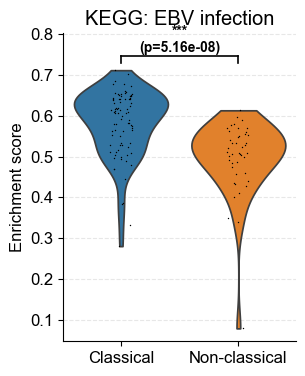

In [ ]:
kegg = gp.get_library('KEGG_2021_Human')
sc.tl.score_genes(adata, gene_list=kegg['Epstein-Barr virus infection'], score_name=f'KEGG_EBV-infection')
fig, ax = plt.subplots(figsize=(3, 4))
ax, stat, stat_name = plot_violin_stats(
    adata=adata,
    gene='KEGG_EBV-infection',
    groupby='kmeans_anno',
    ax=ax,
)
ax.set_title('KEGG: EBV infection')
ax.set_ylabel('Enrichment score')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS5f.pdf")

In [31]:
print(f"--- Statistical Analysis ---")

if isinstance(stat, list):
    #  pairwise comparisons
    for res in stat:
        print(f"Comparison: {res['group1']} vs {res['group2']}")
        print(f"  Direction: {res['direction']}")
        print(f"  Mean ({res['group1']}): {res['mean1']:.4f}")
        print(f"  Mean ({res['group2']}): {res['mean2']:.4f}")
        print(f"  Statistic (U): {res['statistic']:.2f}")
        print(f"  P-value: {res['pvalue']:.4e}")
        print("-" * 30)
else:
    # Global test
    print(f"Global Test: {stat['method']}")
    print(f"  Statistic (H): {stat['statistic']:.2f}")
    print(f"  P-value: {stat['pvalue']:.4e}")

--- Statistical Analysis ---
Comparison: Classical vs Non-classical
  Direction: Classical > Non-classical
  Mean (Classical): 0.5816
  Mean (Non-classical): 0.4981
  Statistic (U): 2934.00
  P-value: 5.1581e-08
------------------------------


#### **Fig. S5g** KEGG pathway enrichment analysis (GSEA) of the Neutrophil extracellular trap formation pathway in Classical (blue) and Non-classical (orange) states. 

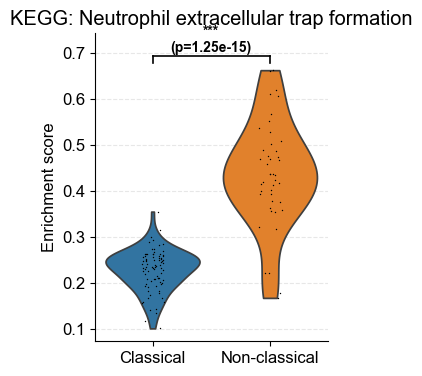

In [ ]:
sc.tl.score_genes(adata, gene_list=kegg['Neutrophil extracellular trap formation'], score_name=f'Neutrophil extracellular trap formation')
fig, ax = plt.subplots(figsize=(3, 4))
ax, stat, stat_name = plot_violin_stats(
    adata=adata,
    gene='Neutrophil extracellular trap formation',
    groupby='kmeans_anno',
    ax=ax,
)
ax.set_title('KEGG: Neutrophil extracellular trap formation')
ax.set_ylabel('Enrichment score')
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS5g.pdf")

In [33]:
print(f"--- Statistical Analysis ---")

if isinstance(stat, list):
    #  pairwise comparisons
    for res in stat:
        print(f"Comparison: {res['group1']} vs {res['group2']}")
        print(f"  Direction: {res['direction']}")
        print(f"  Mean ({res['group1']}): {res['mean1']:.4f}")
        print(f"  Mean ({res['group2']}): {res['mean2']:.4f}")
        print(f"  Statistic (U): {res['statistic']:.2f}")
        print(f"  P-value: {res['pvalue']:.4e}")
        print("-" * 30)
else:
    # Global test
    print(f"Global Test: {stat['method']}")
    print(f"  Statistic (H): {stat['statistic']:.2f}")
    print(f"  P-value: {stat['pvalue']:.4e}")

--- Statistical Analysis ---
Comparison: Classical vs Non-classical
  Direction: Non-classical > Classical
  Mean (Classical): 0.2278
  Mean (Non-classical): 0.4357
  Statistic (U): 253.00
  P-value: 1.2508e-15
------------------------------


#### **Fig. S5h** Stacked barplot of cell-type proportions across the external Bulk RNA-seq dataset evaluated by BayesPrism. 
Columns represent bulk RNA-seq samples, grouped by enrichment for Ma-ligNK_chr6p21Del (left) or MaligNK_chr6p21Amp (right) signatures. Rows denote annotated cell types (e.g., MaligNK_chr6p21Amp, Normal NK); color intensity indicates the relative pro-portion of each cell type per sample (scaled from 0 to 100%).

In [11]:
import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
%load_ext rpy2.ipython
anndata2ri.set_ipython_converter()

In [12]:
# bulk deconvolution
bulk_ad=adata.copy()
single_ad_ref = sc.read_h5ad("./data/NKTCL_concat.h5ad")
# downsampling for single-cell data
sc.pp.subsample(single_ad_ref, n_obs=10000)
# start rpy2 magic
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
# single-cell ref
single_ad_ref.var_names = list(single_ad_ref.var_names)
single_ad_ref.var_names_make_unique()
sc_expr = pd.DataFrame(single_ad_ref.layers['Raw'].todense(), 
                          index=single_ad_ref.obs_names, columns=single_ad_ref.var_names)
cell_type_labels = single_ad_ref.obs["CellTypeLabels"]
# bulk target
bulk_expr = pd.DataFrame(adata.layers['Raw'], 
                          index=adata.obs_names, columns=adata.var_names)
# gene intersections
common_genes = sc_expr.columns.intersection(bulk_expr.columns)
sc_expr = sc_expr[common_genes]
bulk_expr = bulk_expr[common_genes]
print("single-cell shape(cell*gene):", sc_expr.shape)
print("Bulk shape(cell*gene):", bulk_expr.shape)

single-cell shape(cell*gene): (10000, 32116)
Bulk shape(cell*gene): (128, 32116)


Using magic %%R to execute BayesPrism

In [309]:
%%R
library(BayesPrism) 

  cannot shut down device 1 (the null device)
  


In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [310]:
%%R -i sc_expr -i cell_type_labels -i bulk_expr

# ----------------------
# 1. Data format conversion (in R)
# ----------------------
# Single-cell expression matrix (cells × genes)
sc.dat <- as.matrix(sc_expr)  
# Bulk expression matrix (samples × genes)
bk.dat <- as.matrix(bulk_expr)  
# Cell type labels (character vector)
cell.type.labels <- as.character(cell_type_labels)  
cell.state.labels <- cell.type.labels

# Print result preview
print("Cell type proportions:")
print(head(theta))

[1] "Cell type proportions:"
       NK cells Myeloid cells      T cells   Epithelial Plasma cells
T126m 0.3537283  2.687307e-07 1.323673e-07 1.734853e-07 6.733897e-08
T176m 0.5056396  3.430878e-01 1.151373e-04 6.118292e-07 7.885085e-05
T127m 0.3253199  3.440149e-02 4.405816e-07 1.014975e-01 9.553474e-03
T179m 0.4453733  2.748735e-01 5.034637e-07 9.161439e-02 7.629509e-03
T110m 0.5890929  4.173442e-02 2.879887e-07 6.040670e-07 3.505213e-03
T45m  0.4378632  8.668616e-02 9.190281e-08 1.904336e-07 4.066070e-03
      Immune mixed Stromal cells      B cells Endothelial   Mast cells
T126m 5.922472e-05    0.43747422 3.417556e-07  0.20873693 3.373780e-07
T176m 1.568562e-07    0.09961086 4.233770e-03  0.04723311 1.373483e-07
T127m 2.409278e-02    0.22604083 2.211678e-01  0.05787258 5.328247e-05
T179m 1.082593e-07    0.02540542 1.679710e-05  0.15456419 5.222971e-04
T110m 4.596285e-02    0.17767808 6.790878e-02  0.04689461 2.722228e-02
T45m  8.252144e-08    0.41063831 2.221482e-07  0.06074539 2.58

  cannot shut down device 1 (the null device)
  


In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [ ]:
def anno(adata:ad.AnnData, annoDict:dict, obsKey='cnv_status', obsVal='cnv_leiden', default="Unknown"):
  if default is not None:
    adata.obs[obsKey] = default
  for key in annoDict.keys():
    adata.obs.loc[adata.obs[obsVal].isin(annoDict[key]), obsKey] = key
  return adata

annot = {
  'B cells': ['B cells'],
  'Endothelial': ['Endothelial'],
  'Epithelial': ['Epithelial'],
  'Mast cells': ['Mast cells'],
  'Myeloid cells': ['Myeloid cells'],
  'NK cells': ['NK cells', 'NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16',
       'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2', 'NK06: Norm_FGFBP2',
       'NK07: Norm_KIT', 'NK08: Malig_IL2RA', 'NK09: Malig_H2AC11'],
  'Plasma cells': ['Plasma cells'],
  'Stromal cells': ['Stromal cells'],
  'T cells': ['T01: CD8_Tn_CCR7',
       'T02: CD8_Tcm_SELL', 'T03: CD8_Tcm_XCL1', 'T04: Trm_ZNF683',
       'T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4', 'T08: Treg_FOXP3',
       'T09: Th_CXCL13', 'T10: CD4_Tcm_IL7R', 'T11: Tctl_GZMK',
       'T12: Tprol_MKI67', 'T13: Malig_MSI2', 'T14: NK/NKT_NCAM1',
       'T15: mixed'],
}
single_ad_ref = anno(single_ad_ref, annot, 'CellTypeLabels', 'CellStateLabels')

In [327]:
cell_type_labels = single_ad_ref.obs["CellTypeLabels"]
cell_state_labels = single_ad_ref.obs["CellStateLabels"]

In [328]:
%%R -i cell_type_labels -i cell_state_labels
cell.type.labels <- as.character(cell_type_labels)  
cell.state.labels <- as.character(cell_state_labels)

  cannot shut down device 1 (the null device)
  


In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [330]:
%%R
myPrism <- new.prism(
    reference = sc.dat,    
    mixture = bk.dat,          
    input.type = "count.matrix", 
    cell.type.labels = cell.type.labels,
    cell.state.labels = cell.state.labels,              
    key = 'NK cells'
)

number of cells in each cell state 
cell.state.labels
     NK07: Norm_KIT   T14: NK/NKT_NCAM1      T05: tTex_TCF7          Mast cells 
                 31                  33                  49                  51 
NK04: Malig_CD200R1    T01: CD8_Tn_CCR7  NK05: Malig_FGFBP2   T03: CD8_Tcm_XCL1 
                 59                  70                  73                  86 
  NK06: Norm_FGFBP2  NK09: Malig_H2AC11       T07: tTex_CD4    NK03: Malig_CD16 
                 96                 151                 152                 161 
   T12: Tprol_MKI67      T09: Th_CXCL13   NK08: Malig_IL2RA   NK01: Malig_MKI67 
                177                 188                 189                 232 
           NK cells         Endothelial      T11: Tctl_GZMK   T10: CD4_Tcm_IL7R 
                238                 244                 250                 259 
       Plasma cells          T15: mixed       T06: tTex_CD8      T04: pTex_IFNG 
                263                 283                

  cannot shut down device 1 (the null device)
  


In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [331]:
%%R
# ----------------------
# 3. Run BayesPrism deconvolution
# ----------------------
bp.res <- run.prism(
    prism = myPrism,
    n.cores = 24,       # Number of CPU cores (for acceleration)
)

Run Gibbs sampling... 
Current time:  2025-12-04 10:03:29.981186 
Estimated time to complete:  1hrs 9mins 
Estimated finishing time:  2025-12-04 11:11:37.421186 
Start run... 
Update the reference matrix ... 
Run Gibbs sampling using updated reference ... 
Current time:  2025-12-04 10:40:58.43652 
Estimated time to complete:  42mins 
Estimated finishing time:  2025-12-04 11:22:25.79652 
Start run... 


  cannot shut down device 1 (the null device)
  


snowfall 1.84-6.3 initialized (using snow 0.4-4): parallel execution on 24 CPUs.


Stopping cluster

snowfall 1.84-6.3 initialized (using snow 0.4-4): parallel execution on 24 CPUs.


Stopping cluster

snowfall 1.84-6.3 initialized (using snow 0.4-4): parallel execution on 24 CPUs.


Stopping cluster

In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [342]:
%%R
# ----------------------
# 4. Extract results
# ----------------------
# Cell type proportions (samples × cell types)
theta <- get.fraction(
    bp = bp.res,
    which.theta = "final",
    state.or.type = "type"
)

# Cell-type specific expression (genes × cell types)
cell.expr <- get.exp(
    bp = bp.res,
    state.or.type = "type"
)

theta_state <- bp.res@posterior.initial.cellState@theta

  cannot shut down device 1 (the null device)
  


Error in file(out, "wt") : cannot open the connection
In addition: Warning message:
In file(out, "wt") :
  cannot open file '/tmp/Rtmpjo420d/Rtxt31ab3f553d198c': No such file or directory
In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [ ]:
%%R -o theta_state -o cell.expr
write.csv(theta_state, file='./data/theta_state.csv', quote=F)

  cannot shut down device 1 (the null device)
  


In addition: Warning message:
In (function (filename = "Rplot%03d.png", width = 480, height = 480,  :
  failed to load cairo DLL


In [ ]:
theta_state = pd.read_csv("./data/theta_state.csv", index_col=0)
theta_state

,Myeloid cells,T11: Tctl_GZMK,T13: Malig_MSI2,NK02: Malig_CD56,Epithelial,Plasma cells,T15: mixed,Stromal cells,B cells,T12: Tprol_MKI67,...,T01: CD8_Tn_CCR7,NK03: Malig_CD16,NK05: Malig_FGFBP2,T14: NK/NKT_NCAM1,Mast cells,NK09: Malig_H2AC11,T03: CD8_Tcm_XCL1,T05: tTex_TCF7,T09: Th_CXCL13,NK06: Norm_FGFBP2
T126m,0.000015,2.193620e-07,4.548294e-07,2.499510e-07,3.112293e-07,5.348905e-08,3.443598e-07,0.488279,6.805480e-06,2.835151e-04,...,3.122585e-07,1.912337e-06,1.832189e-07,1.491546e-07,7.942922e-07,0.137143,2.146255e-07,3.082531e-07,2.991832e-07,2.880733e-07
T176m,0.320668,1.422675e-07,4.920566e-04,1.503813e-07,6.597053e-07,2.431233e-06,2.189910e-07,0.117289,2.996590e-04,9.700364e-02,...,2.450332e-07,1.393957e-02,1.536477e-07,8.675687e-07,1.477440e-07,0.097789,2.311222e-07,5.056889e-07,2.742177e-07,1.244109e-06
T127m,0.045647,3.908372e-07,2.511927e-03,2.466428e-07,1.206952e-01,7.517287e-03,4.181964e-07,0.239194,2.046497e-01,9.848265e-07,...,3.406852e-07,8.232466e-07,2.723058e-07,2.606893e-07,4.032439e-07,0.169734,3.366466e-07,3.545585e-07,3.324629e-07,3.975002e-07
T179m,0.259240,1.979498e-07,2.004050e-06,1.550098e-07,1.331037e-01,6.877862e-03,2.199880e-07,0.032109,6.251042e-03,1.259513e-01,...,2.381638e-07,1.983219e-04,2.341341e-07,4.651666e-07,4.818322e-04,0.086552,3.251033e-07,1.036419e-04,2.936608e-07,3.444604e-07
T110m,0.057820,1.618516e-07,1.918256e-02,1.278923e-07,2.194634e-03,2.243204e-03,3.263493e-07,0.190949,8.948943e-03,2.238060e-05,...,2.177333e-07,2.984927e-06,1.722181e-07,1.755957e-07,5.094565e-04,0.172766,1.911720e-07,2.376190e-07,1.878270e-07,1.838949e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T92m,0.212328,2.568076e-07,5.701610e-07,4.202851e-07,3.350072e-02,5.563347e-03,2.367928e-07,0.024112,2.704352e-03,1.712112e-01,...,2.656229e-07,1.670985e-01,3.523409e-07,1.280957e-03,2.172432e-07,0.120556,4.588653e-07,5.235974e-07,3.419961e-07,6.932824e-07
T53m,0.263872,1.651453e-07,1.089780e-06,2.262852e-07,1.202133e-07,3.097780e-04,1.531528e-07,0.148605,1.799282e-02,6.208223e-02,...,1.561319e-07,1.017729e-01,2.238953e-07,6.320230e-07,1.343150e-07,0.093965,2.376115e-07,4.830887e-07,2.084921e-07,4.660336e-07
T99m,0.115679,5.099602e-07,6.133140e-07,1.269377e-07,3.120893e-02,2.423408e-03,9.650268e-08,0.480747,9.708405e-03,4.611130e-07,...,2.256248e-07,2.009775e-07,1.892963e-07,1.948269e-07,2.396271e-03,0.043076,4.312271e-07,2.481377e-07,4.153197e-07,8.943545e-07
T147m,0.125552,1.342058e-07,1.029586e-01,1.761749e-07,1.208822e-07,7.763592e-02,1.510998e-07,0.030361,2.082738e-01,7.750192e-02,...,2.085161e-07,6.387455e-07,2.598666e-07,2.110892e-06,2.965973e-04,0.085254,3.225580e-07,2.989378e-07,9.450796e-07,1.369175e-06


In [81]:
def correlate_cell_proportion_and_gene_expression(cell_type, gene_name, theta_state, adata):
    """
    Calculate Pearson correlation between a specific cell type's proportion and a target gene's expression,
    and visualize the relationship with a scatter plot.
    
    Parameters:
        cell_type (str): Name of the target cell type (must match the key in theta_state)
        gene_name (str): Name of the target gene (must match the gene name in adata)
        theta_state (dict): Dictionary containing cell type proportions, with cell type as key
        adata (anndata.AnnData): AnnData object containing the gene expression data
    
    Returns:
        tuple: Pearson correlation coefficient and corresponding p-value
    """
    # Extract the proportion of the target cell type
    cell_proportion = list(theta_state[cell_type])
    
    # Extract the expression level of the target gene and flatten to 1D array
    gene_expression = list(adata[:, gene_name].X.flatten())
    
    # Calculate Pearson correlation coefficient and p-value
    corr, p_value = pearsonr(cell_proportion, gene_expression)
    
    # Print correlation result
    print(f"Correlation between {cell_type} proportion and {gene_name} expression: {corr:.3f} (p-value: {p_value:.3e})")
    
    # Visualize the relationship with scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(cell_proportion, gene_expression, alpha=0.6, s=30)
    plt.xlabel(f'{cell_type} Proportion', fontsize=12)
    plt.ylabel(f'{gene_name} Expression', fontsize=12)
    plt.title(f'Correlation: r = {corr:.3f}, p = {p_value:.3e}', fontsize=14, pad=10)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Return correlation results
    return corr, p_value

In [ ]:
theta = theta_state.copy()
theta['Malig NK chr6+'] = theta[['NK cells','NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16', 'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2',]].sum(axis=1)
theta['Malig NK chr6-'] = theta[['NK08: Malig_IL2RA','NK09: Malig_H2AC11']].sum(axis=1)
theta['Normal NK'] = theta[['T14: NK/NKT_NCAM1','NK07: Norm_KIT', 'NK06: Norm_FGFBP2']].sum(axis=1)
theta['Malig T'] = theta[['T13: Malig_MSI2','T12: Tprol_MKI67', 'T15: mixed']].sum(axis=1)
theta['Normal CD8T'] = theta[['T01: CD8_Tn_CCR7', 'T02: CD8_Tcm_SELL', 'T03: CD8_Tcm_XCL1',
       'T04: Trm_ZNF683', 'T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4']].sum(axis=1)
theta['Normal CD4T'] = theta[['T08: Treg_FOXP3', 'T09: Th_CXCL13', 'T10: CD4_Tcm_IL7R','T11: Tctl_GZMK',]].sum(axis=1)
theta = theta[['Malig NK chr6+', 'Malig NK chr6-', 'Malig T', 
               'Normal NK', 'Normal CD8T', 'Normal CD4T', 'B cells',
               'Myeloid cells', 'Plasma cells', 'Epithelial', 'Stromal cells', 'Endothelial',  'Mast cells',]]
theta

,Malig NK chr6+,Malig NK chr6-,Malig T,Normal NK,Normal CD8T,Normal CD4T,B cells,Myeloid cells,Plasma cells,Epithelial,Stromal cells,Endothelial,Mast cells
T126m,0.000165,0.249827,0.000284,8.953127e-07,0.000002,1.263640e-06,6.805480e-06,0.000015,5.348905e-08,3.112293e-07,0.488279,0.261417,7.942922e-07
T176m,0.120035,0.236405,0.097496,7.490863e-02,0.000002,1.265455e-06,2.996590e-04,0.320668,2.431233e-06,6.597053e-07,0.117289,0.032892,1.477440e-07
T127m,0.000003,0.311712,0.002513,1.962156e-06,0.000003,1.511870e-06,2.046497e-01,0.045647,7.517287e-03,1.206952e-01,0.239194,0.068062,4.032439e-07
T179m,0.026189,0.219157,0.125954,5.196862e-02,0.000106,1.371763e-06,6.251042e-03,0.259240,6.877862e-03,1.331037e-01,0.032109,0.138561,4.818322e-04
T110m,0.001892,0.647956,0.019205,2.259859e-02,0.000001,1.074663e-06,8.948943e-03,0.057820,2.243204e-03,2.194634e-03,0.190949,0.045681,5.094565e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
T92m,0.377307,0.120556,0.171212,1.283226e-03,0.000003,1.236275e-06,2.704352e-03,0.212328,5.563347e-03,3.350072e-02,0.024112,0.051428,2.172432e-07
T53m,0.183005,0.173904,0.062083,3.336648e-02,0.000002,7.764198e-07,1.799282e-02,0.263872,3.097780e-04,1.202133e-07,0.148605,0.116858,1.343150e-07
T99m,0.002724,0.043077,0.000001,1.537819e-06,0.000043,1.586873e-06,9.708405e-03,0.115679,2.423408e-03,3.120893e-02,0.480747,0.311989,2.396271e-03
T147m,0.000003,0.254473,0.180461,4.251487e-02,0.000003,1.954859e-06,2.082738e-01,0.125552,7.763592e-02,1.208822e-07,0.030361,0.080424,2.965973e-04


CXCL13与CD274的共表达相关性：0.487（p值：5.428e-09）


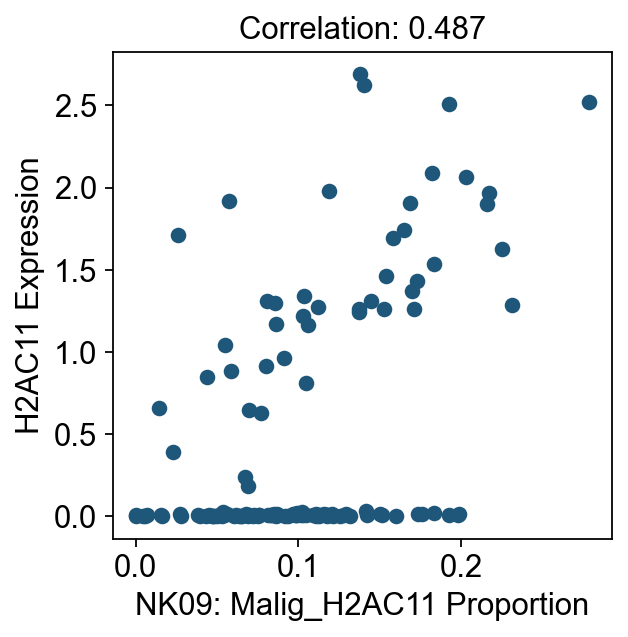

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Data Extraction
# Extract the proportion values for the specific cell state 'NK09: Malig_H2AC11' from theta_state
# This represents the abundance of this specific malignant cluster across samples/cells
MaligNK_prop = list(theta_state['NK09: Malig_H2AC11'])

# Extract the gene expression values for 'H2AC11' from the AnnData object
# We flatten the matrix to get a 1D array of expression levels
H2AC11_expr = list(adata[:,'H2AC11'].X.flatten())

# 2. Statistical Analysis
# Calculate Pearson correlation coefficient and p-value to assess linear correlation
corr, p_value = pearsonr(MaligNK_prop, H2AC11_expr)

# Print the results (Note: updated text to reflect H2AC11 instead of the old CXCL13/CD274)
print(f"Correlation between NK09 proportion and H2AC11 expression: {corr:.3f} (p-value: {p_value:.3e})")

# 3. Visualization
plt.figure(figsize=(6, 5)) # Optional: set figure size
plt.scatter(MaligNK_prop, H2AC11_expr, alpha=0.6, color='blue') # Added alpha for better visibility if points overlap

# Set axis labels
plt.xlabel('NK09: Malig_H2AC11 Proportion')
plt.ylabel('H2AC11 Expression Level')

# Set title with the calculated correlation coefficient
plt.title(f'Correlation: r = {corr:.3f}, P = {p_value:.3e}')

# Display the plot
plt.show()

Correlation between Malig NK chr6- proportion and ZEB1 expression: 0.630 (p-value: 1.607e-15)


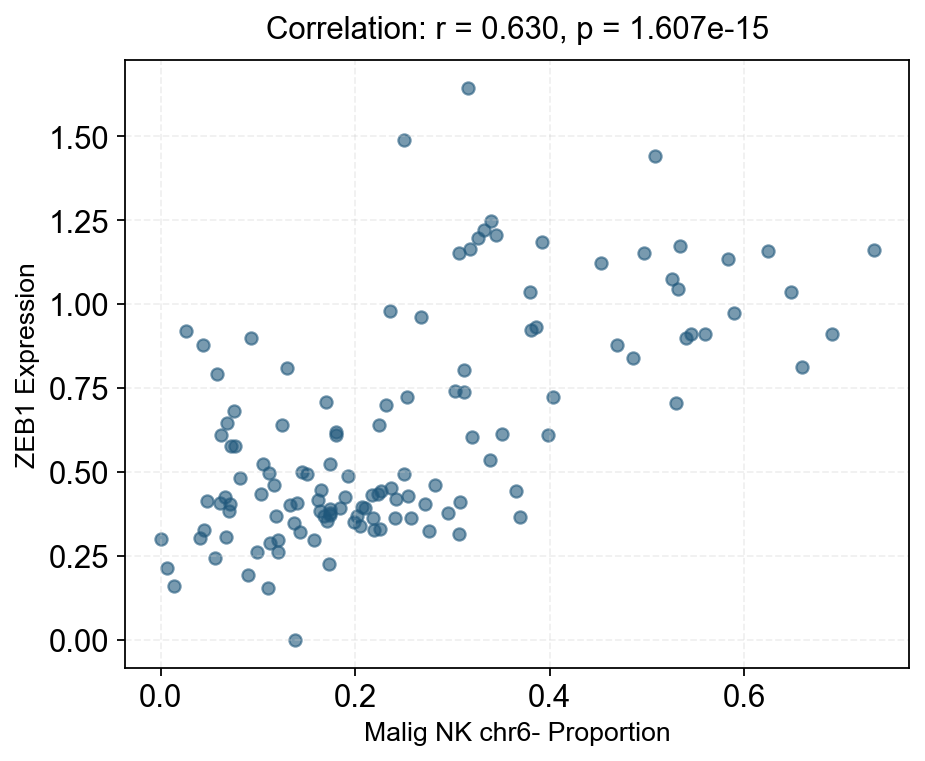

In [99]:
corr_result, p_val_result = correlate_cell_proportion_and_gene_expression(
    cell_type="Malig NK chr6-",
    gene_name='ZEB1',
    theta_state=theta,
    adata=adata
)

In [18]:
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, PercentFormatter
def propPlot(age_df, barlabels, ax, colors=sc.pl.palettes.default_20, xlabel='Patient ID', show_y=True, xrotate=90):
    all_df = age_df.sum(axis=1)
    age_normdf = pd.DataFrame([age_df.loc[i,:]/all_df[i] for i in barlabels], index=barlabels)
    age_cumdf = pd.DataFrame([np.cumsum(age_normdf.loc[i,:]) for i in barlabels], index=barlabels)
    norm_gdfs = age_normdf
    cum_gdfs = age_cumdf
    for i, col in enumerate(age_df.columns):
        height = norm_gdfs[col]
        starts = cum_gdfs[col] - height
        rects = ax.bar(barlabels, height, bottom=starts, width=0.9, color=colors[i], edgecolor='white', linewidth=0.5)
    
        # ax.bar_label(rects,age_df.loc[:, col], label_type='center', color='lightgrey', fontsize=14)
    ax.legend( 
              handletextpad=0.5, frameon=False,
                          borderpad=0.4,
                          columnspacing=1,
                          handlelength=0.65,
              loc='best')
    if show_y:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1,decimals=0))
        ax.set_ylabel('Cell proportions')
    else:
        ax.yaxis.set_visible(False)
    ax.set_ylabel(xlabel)
    # ax.set_yticks(barlabels)
    ax.set_xticklabels(labels=barlabels,rotation=90, fontsize=8)
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

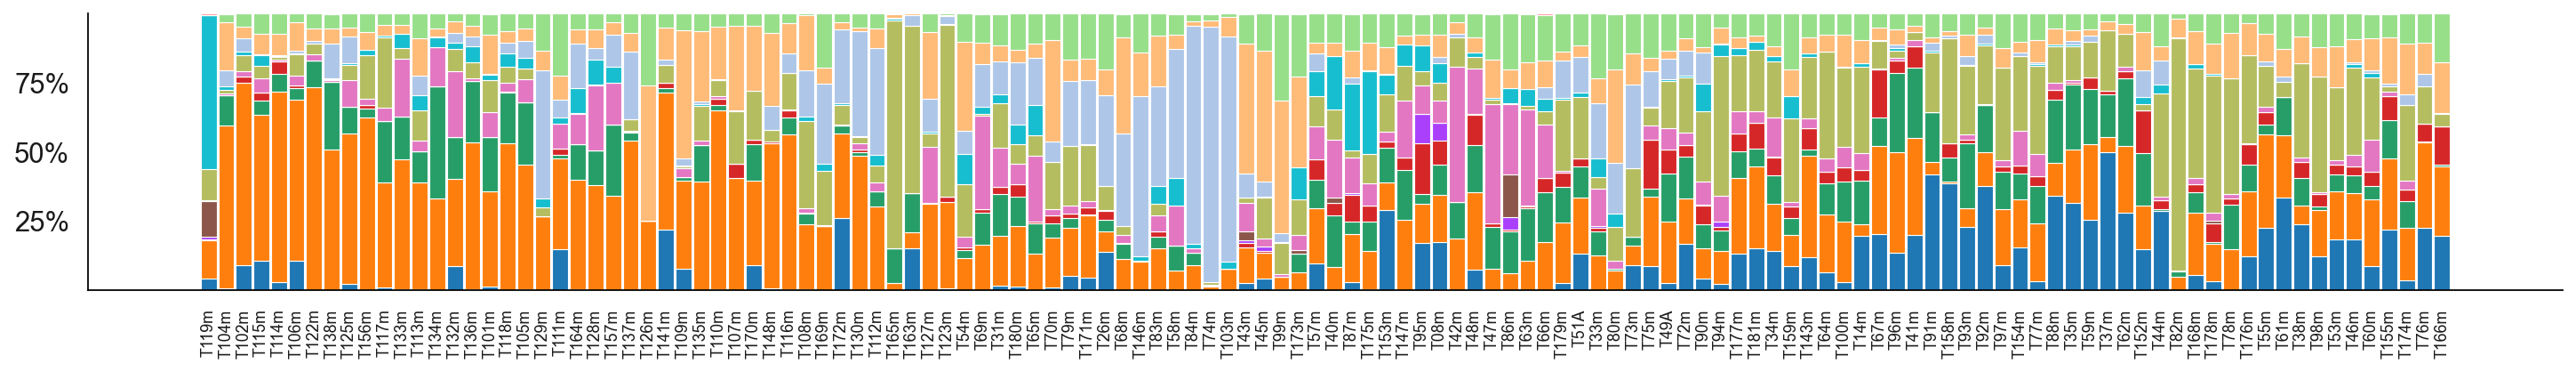

In [ ]:
barlabels = dendrogram(linkage_matrix, labels=adata.obs_names, color_threshold=7, ax=ax)['ivl']
fig0, ax0 = plt.subplots(figsize=(18, 2.5), constrained_layout=True)
propPlot(theta, ax=ax0, barlabels=barlabels, xlabel='', show_y=True)
fig0.savefig(f"{figPath}/FigS5h-prop.pdf")